In [3]:
import numpy as np

dt = 0.2 # time step
gamma = 0.99
d_safe = 1.0 # collision radius, set kinda high
max_d = 20.0 # this is silly but to keep it from runnnig away forever
max_v = 5.0 

thrust = 0.5 # acceleration magnitude simplification
fuel_cost = -1 # probably should tune st that model is more sane
collision_penalty = -100

# discretization
d_bins = 50
v_bins = 50
d_vals = np.linspace(0, max_d, d_bins)
v_vals = np.linspace(-max_v, max_v, v_bins)

# actions = [accelerate inward, do nothing, accelerate outward]
actions = [-thrust, 0.0, thrust]

def get_next_state(d, v, a):
    """
        r' = r + v * dt
        v' = v + a * dt
    """
    d_next = d + v * dt
    v_next = v + a * dt

    # keep in bounds
    d_next = np.clip(d_next, 0, max_d)
    v_next = np.clip(v_next, -max_v, max_v)


    return d_next, v_next


def is_collision(d):
    return d <= d_safe

def reward(d, a):

    if is_collision(d):
        return collision_penalty
    elif a != 0:
        return fuel_cost
    else:
        return 0.0


def get_nearest_bin(r, v):
    d_idx = np.argmin(np.abs(d_vals - d))
    v_idx = np.argmin(np.abs(v_vals - v))
    return d_idx, v_idx


# value iteration
V = np.zeros((d_bins, v_bins))
policy = np.zeros((d_bins, v_bins))

max_iters = 200
epsilon = 1e-4 # could perhaps modify

for it in range(max_iters):
    delta = 0
    V_new = np.copy(V)
    for i, d in enumerate(d_vals):
        for j, v in enumerate(v_vals):
            best_value = -np.inf
            best_action = 0
            for a in actions:
                d_next, v_next = get_next_state(d, v, a)
                new_i, new_j = get_nearest_bin(d_next, v_next)

                val = reward(d, a) + gamma * V[new_i, new_j]
                # if a == thrust:
                #     print("val, reward, action: ", val, reward(d,a), a)
                #     print(reward(d, 0))
                if val > best_value or a > 0:
                    best_value = val
                    best_action = a
                # if val == best_value:
                #     the same, need to think about maybe what to do here

            V_new[i, j] = best_value
            policy[i, j] = best_action

            delta = max(delta, abs(V_new[i, j] - V[i, j]))

    V = V_new

    if delta < epsilon:
        print("Converged at step ", it)
        break


def simulate(d0, v0, steps=50):
    d, v = d0, v0
    traj = []

    for t in range(steps):
        i, j = get_nearest_bin(d, v)
        a = policy[i, j]
        rew = reward(d, a)

        traj.append((d, v, a, rew))

        if is_collision(d):
            print("Collision at step ", t)
            break

        d, v = get_next_state(d, v, a)

    return traj

print(policy)


print("Starting simulation \n")
traj = simulate(d0=2.0, v0=-.2, steps=30)

print("\nTrajectory (d, v, action, reward):")
for step in traj:
    print(step)


    

[[0.5 0.5 0.5 ... 0.5 0.5 0.5]
 [0.5 0.5 0.5 ... 0.5 0.5 0.5]
 [0.5 0.5 0.5 ... 0.5 0.5 0.5]
 ...
 [0.5 0.5 0.5 ... 0.5 0.5 0.5]
 [0.5 0.5 0.5 ... 0.5 0.5 0.5]
 [0.5 0.5 0.5 ... 0.5 0.5 0.5]]
Starting simulation 


Trajectory (d, v, action, reward):
(2.0, -0.2, np.float64(0.5), -1)
(np.float64(1.96), np.float64(-0.1), np.float64(0.5), -1)
(np.float64(1.94), np.float64(0.0), np.float64(0.5), -1)
(np.float64(1.94), np.float64(0.1), np.float64(0.5), -1)
(np.float64(1.96), np.float64(0.2), np.float64(0.5), -1)
(np.float64(2.0), np.float64(0.30000000000000004), np.float64(0.5), -1)
(np.float64(2.06), np.float64(0.4), np.float64(0.5), -1)
(np.float64(2.14), np.float64(0.5), np.float64(0.5), -1)
(np.float64(2.24), np.float64(0.6), np.float64(0.5), -1)
(np.float64(2.3600000000000003), np.float64(0.7), np.float64(0.5), -1)
(np.float64(2.5000000000000004), np.float64(0.7999999999999999), np.float64(0.5), -1)
(np.float64(2.6600000000000006), np.float64(0.8999999999999999), np.float64(0.5), -1)
(n

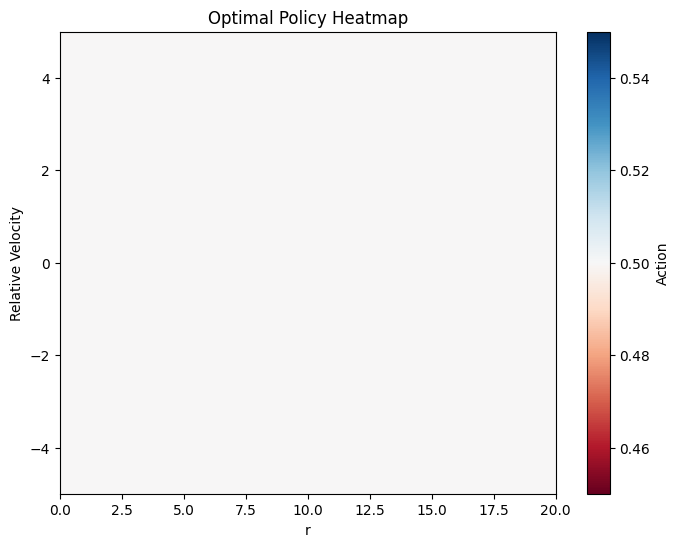

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.imshow(
    policy.T,
    origin="lower",
    extent=[0, max_d, -max_v, max_v],
    aspect="auto",
    cmap="RdBu"
)

plt.colorbar(label="Action")
plt.xlabel("r")
plt.ylabel("Relative Velocity")
plt.title("Optimal Policy Heatmap")

plt.show()